# RQ9 — Universal Cross-Wheel Event

## Research question

> Can one wheel-invariant acoustic event detector identify the true-gate candidate on a wheel that was completely absent from training?

RQ8 showed that a local release-like event exists, particularly for W2, but its timing and strength are wheel-dependent. RQ9 therefore tests the stronger physical hypothesis:

> the same acoustic event is sufficiently universal across wheels that one shared detector can learn it from two wheels and recognise the third.

This is intentionally a **shortcut-resistant test**. A universal detector is not allowed to exploit wheel identity, absolute acoustic level, candidate digit, or transition identity.

### Historical result

The project history records a `Shared Event Ranker v3` with the same scientific purpose:

- no wheel ID;
- no absolute acoustic fingerprint;
- normalised event-like features only;
- leave-one-wheel-out validation;
- Top-1 only around **7–13%**.

The exact serialized historical ranker and exact per-wheel result table were not recovered. The historical value is therefore retained as an audit reference, not presented as a fresh replay.

### Fresh controlled reconstruction

The reconstruction uses the controlled RQ1–4 dataset:

- password **3517**
- loaded state
- direction **CCW**
- wheels **W1, W2 and W4**
- 10 scans per wheel
- 10 candidates per scan
- **30 scans / 300 candidate movements**

Only the cached movement envelopes and motion duration are used.

### Shortcut restrictions

For every candidate:

1. target and reference envelopes are transformed to log amplitude;
2. each envelope is individually centred and scaled, removing absolute level;
3. only envelope-shape, multi-peak and temporal-transient summaries are retained;
4. target-reference transient summaries and two cross-channel correlations are added;
5. motion duration is included only before a second **within-scan** robust normalisation across the ten candidates.

The model never receives:

- wheel ID;
- digit / transition identity;
- raw amplitude;
- raw spectral fingerprint.

### Validation

Three leave-one-wheel-out folds are performed:

- train W2 + W4 → test W1
- train W1 + W4 → test W2
- train W1 + W2 → test W4

The held-out wheel is absent from model fitting and scaling.

The primary endpoint is **Top-1 10-way ranking accuracy**.

Random ranking gives:

- Top-1 = 10%
- Top-2 = 20%
- Top-3 = 30%
- mean true rank = 5.5

A useful universal detector should outperform these baselines consistently on all three unseen wheels.

## 1. Load the controlled validity dataset

In [1]:
from google.colab import drive
from pathlib import Path
import json

import numpy as np
import pandas as pd
from IPython.display import display

drive.mount(
    "/content/drive"
)

MYDRIVE = Path(
    "/content/drive/MyDrive"
)

PROJECT_ROOT = (
    MYDRIVE
    / "Padlock_Reproduction_v1"
)

results_candidates = [
    PROJECT_ROOT / "results",
    PROJECT_ROOT
    / "Padlock_Reproduction_v1"
    / "results",
]

RESULTS_ROOT = next(
    (
        p
        for p in results_candidates
        if (
            p
            / "00_RQ1-4_QC"
            / "RQ1-4_qc_manifest.csv"
        ).exists()
    ),
    None,
)

if RESULTS_ROOT is None:
    raise FileNotFoundError(
        "Could not locate Padlock_Reproduction_v1/results."
    )

MANIFEST_PATH = (
    RESULTS_ROOT
    / "00_RQ1-4_QC"
    / "RQ1-4_qc_manifest.csv"
)

CACHE_PATH = (
    RESULTS_ROOT
    / "feature_cache"
    / "RQ1-4_interpretable_v1.npz"
)

RESULT_DIR = (
    RESULTS_ROOT
    / "09_RQ9_Universal_CrossWheel_Event"
)

RESULT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

manifest = pd.read_csv(
    MANIFEST_PATH
)

cache = np.load(
    CACHE_PATH,
    allow_pickle=False,
)

env_target = cache[
    "env_target"
]

env_reference = cache[
    "env_reference"
]

cache_run_ids = cache[
    "run_ids"
].astype(str)

if not np.array_equal(
    manifest[
        "run_id"
    ].astype(str).to_numpy(),
    cache_run_ids,
):
    raise RuntimeError(
        "Feature-cache order does not match the QC manifest."
    )

mask = (
    manifest[
        "tension_state"
    ].eq("LOADED")
    &
    manifest[
        "wheel"
    ].isin(
        [
            1,
            2,
            4,
        ]
    )
    &
    manifest[
        "direction"
    ].eq("CCW")
)

data = (
    manifest.loc[
        mask
    ]
    .copy()
    .reset_index(
        drop=True
    )
)

env_t = env_target[
    mask.to_numpy()
]

env_r = env_reference[
    mask.to_numpy()
]

assert len(
    data
) == 300

assert data[
    "scan_id"
].nunique() == 30

assert data.groupby(
    "scan_id"
).size().eq(10).all()

assert data.groupby(
    "scan_id"
)[
    "is_true_gate"
].sum().eq(1).all()

print(
    "Scans:",
    data[
        "scan_id"
    ].nunique(),
)

print(
    "Candidates:",
    len(
        data
    ),
)

display(
    data.groupby(
        "wheel"
    ).agg(
        scans=(
            "scan_id",
            "nunique",
        ),
        candidates=(
            "run_id",
            "size",
        ),
    )
)

Mounted at /content/drive
Scans: 30
Candidates: 300


,scans,candidates
wheel,,
1,10,100
2,10,100
4,10,100


## 2. Build the shortcut-resistant event representation

The representation is intentionally lower-level than the final true-gate model. It keeps only normalised event shape and transient structure.

No feature in this section contains a wheel label or physical digit.

In [2]:
from scipy.signal import find_peaks

EPS = 1e-12
PEAK_PROMINENCE = 0.5
CLIP = 8.0


def normalised_log_envelope(
    x
):
    x = np.asarray(
        x,
        dtype=float,
    )

    log_x = np.log(
        x + EPS
    )

    centred = (
        log_x
        - np.median(
            log_x
        )
    )

    mad = np.median(
        np.abs(
            centred
        )
    )

    robust_scale = (
        1.4826
        * mad
    )

    std = np.std(
        centred
    )

    scale = (
        robust_scale
        if robust_scale > 1e-6
        else (
            std
            if std > 1e-6
            else 1.0
        )
    )

    return np.clip(
        centred
        / scale,
        -CLIP,
        CLIP,
    )


def envelope_shape_summary(
    x
):
    x = np.asarray(
        x,
        dtype=float,
    )

    dx = np.diff(
        x
    )

    idx = np.linspace(
        0.0,
        1.0,
        len(
            x
        ),
    )

    peaks, peak_props = find_peaks(
        x,
        prominence=PEAK_PROMINENCE,
    )

    troughs, _ = find_peaks(
        -x,
        prominence=PEAK_PROMINENCE,
    )

    if len(
        peaks
    ):
        prominences = peak_props[
            "prominences"
        ]

        mean_prominence = float(
            np.mean(
                prominences
            )
        )

        max_prominence = float(
            np.max(
                prominences
            )
        )

    else:
        mean_prominence = 0.0
        max_prominence = 0.0

    q10, q25, q50, q75, q90 = np.quantile(
        x,
        [
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
        ],
    )

    quartile_means = [
        float(
            np.mean(
                x[0:16]
            )
        ),
        float(
            np.mean(
                x[16:32]
            )
        ),
        float(
            np.mean(
                x[32:48]
            )
        ),
        float(
            np.mean(
                x[48:64]
            )
        ),
    ]

    return np.array(
        [
            float(
                np.std(
                    x
                )
            ),
            float(
                q90
                - q10
            ),
            float(
                q75
                - q25
            ),
            float(
                np.mean(
                    np.abs(
                        dx
                    )
                )
            ),
            float(
                np.max(
                    np.abs(
                        dx
                    )
                )
            ),
            float(
                len(
                    peaks
                )
            ),
            float(
                len(
                    troughs
                )
            ),
            mean_prominence,
            max_prominence,
            float(
                idx[
                    np.argmax(
                        x
                    )
                ]
            ),
            float(
                idx[
                    np.argmin(
                        x
                    )
                ]
            ),
            *quartile_means,
        ],
        dtype=float,
    )


def build_event_features(
    target_env,
    reference_env,
    motion_duration_s,
):
    rows = []

    for (
        target,
        reference,
        duration,
    ) in zip(
        target_env,
        reference_env,
        motion_duration_s,
    ):
        target_norm = (
            normalised_log_envelope(
                target
            )
        )

        reference_norm = (
            normalised_log_envelope(
                reference
            )
        )

        transient_diff = (
            target_norm
            - reference_norm
        )

        target_summary = (
            envelope_shape_summary(
                target_norm
            )
        )

        reference_summary = (
            envelope_shape_summary(
                reference_norm
            )
        )

        transient_summary = (
            envelope_shape_summary(
                transient_diff
            )
        )

        corr = (
            float(
                np.corrcoef(
                    target_norm,
                    reference_norm,
                )[0, 1]
            )
            if (
                np.std(
                    target_norm
                )
                > 1e-9
                and
                np.std(
                    reference_norm
                )
                > 1e-9
            )
            else 0.0
        )

        target_dx = np.diff(
            target_norm
        )

        reference_dx = np.diff(
            reference_norm
        )

        derivative_corr = (
            float(
                np.corrcoef(
                    target_dx,
                    reference_dx,
                )[0, 1]
            )
            if (
                np.std(
                    target_dx
                )
                > 1e-9
                and
                np.std(
                    reference_dx
                )
                > 1e-9
            )
            else 0.0
        )

        rows.append(
            np.concatenate(
                [
                    target_summary,
                    reference_summary,
                    transient_summary,
                    np.array(
                        [
                            corr,
                            derivative_corr,
                            float(
                                duration
                            ),
                        ]
                    ),
                ]
            )
        )

    return np.vstack(
        rows
    )


X_event_raw = build_event_features(
    env_t,
    env_r,
    data[
        "motion_duration_s"
    ].to_numpy(
        dtype=float
    ),
)

print(
    "Raw event features:",
    X_event_raw.shape,
)

Raw event features: (300, 48)


In [3]:
def within_scan_relative(
    X,
    meta,
):
    out = np.empty_like(
        X,
        dtype=float,
    )

    for (
        scan_id,
        group,
    ) in meta.groupby(
        "scan_id",
        sort=False,
    ):
        idx = group.index.to_numpy()

        x = X[
            idx
        ]

        median = np.median(
            x,
            axis=0,
        )

        mad = np.median(
            np.abs(
                x
                - median
            ),
            axis=0,
        )

        std = np.std(
            x,
            axis=0,
        )

        robust_scale = (
            1.4826
            * mad
        )

        scale = np.where(
            robust_scale
            > 1e-6,
            robust_scale,
            np.where(
                std
                > 1e-6,
                std,
                1.0,
            ),
        )

        out[
            idx
        ] = np.clip(
            (
                x
                - median
            )
            / scale,
            -CLIP,
            CLIP,
        )

    return out


X_event = within_scan_relative(
    X_event_raw,
    data,
)

assert np.isfinite(
    X_event
).all()

feature_group_counts = pd.DataFrame(
    [
        {
            "group": (
                "Target envelope shape"
            ),
            "n_features": len(
                envelope_shape_summary(
                    np.zeros(
                        64
                    )
                )
            ),
        },
        {
            "group": (
                "Reference envelope shape"
            ),
            "n_features": len(
                envelope_shape_summary(
                    np.zeros(
                        64
                    )
                )
            ),
        },
        {
            "group": (
                "Target-reference transient"
            ),
            "n_features": len(
                envelope_shape_summary(
                    np.zeros(
                        64
                    )
                )
            ),
        },
        {
            "group": (
                "Cross-channel correlations"
            ),
            "n_features": 2,
        },
        {
            "group": (
                "Motion duration"
            ),
            "n_features": 1,
        },
    ]
)

feature_group_counts.to_csv(
    RESULT_DIR
    / "RQ9_feature_groups.csv",
    index=False,
)

display(
    feature_group_counts
)

print(
    "Final event feature count:",
    X_event.shape[
        1
    ],
)

,group,n_features
0,Target envelope shape,15
1,Reference envelope shape,15
2,Target-reference transient,15
3,Cross-channel correlations,2
4,Motion duration,1


Final event feature count: 48


## 3. Leave one complete wheel out

A deliberately low-capacity linear ranker is used. `C=0.01` is fixed before the three wheel folds and is not tuned per held-out wheel.

In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

LOGREG_C = 0.01
RANDOM_STATE = 20260819

decision_rows = []
candidate_parts = []

for heldout_wheel in [
    1,
    2,
    4,
]:
    train_mask = data[
        "wheel"
    ].ne(
        heldout_wheel
    ).to_numpy()

    test_mask = data[
        "wheel"
    ].eq(
        heldout_wheel
    ).to_numpy()

    scaler = StandardScaler()

    X_train = scaler.fit_transform(
        X_event[
            train_mask
        ]
    )

    X_test = scaler.transform(
        X_event[
            test_mask
        ]
    )

    y_train = data.loc[
        train_mask,
        "is_true_gate",
    ].to_numpy(
        dtype=int
    )

    model = LogisticRegression(
        C=LOGREG_C,
        solver="liblinear",
        class_weight="balanced",
        max_iter=3000,
        random_state=RANDOM_STATE,
    )

    model.fit(
        X_train,
        y_train,
    )

    scores = model.decision_function(
        X_test
    )

    test = data.loc[
        test_mask
    ].copy()

    test[
        "heldout_wheel"
    ] = heldout_wheel

    test[
        "event_score"
    ] = scores

    candidate_parts.append(
        test
    )

    for (
        scan_id,
        group,
    ) in test.groupby(
        "scan_id",
        sort=False,
    ):
        ranked = (
            group
            .sort_values(
                "event_score",
                ascending=False,
            )
            .reset_index(
                drop=True
            )
        )

        true_index = np.flatnonzero(
            ranked[
                "is_true_gate"
            ].to_numpy(
                dtype=int
            )
            == 1
        )

        if len(
            true_index
        ) != 1:
            raise RuntimeError(
                (
                    heldout_wheel,
                    scan_id,
                    true_index,
                )
            )

        true_rank = int(
            true_index[
                0
            ]
            + 1
        )

        decision_rows.append({
            "heldout_wheel": heldout_wheel,
            "scan_id": int(
                scan_id
            ),
            "truth_digit": int(
                ranked[
                    "truth_digit"
                ].iloc[
                    0
                ]
            ),
            "predicted_digit": int(
                ranked[
                    "after_digit"
                ].iloc[
                    0
                ]
            ),
            "true_rank": true_rank,
            "top1": int(
                true_rank
                <= 1
            ),
            "top2": int(
                true_rank
                <= 2
            ),
            "top3": int(
                true_rank
                <= 3
            ),
            "reciprocal_rank": (
                1.0
                / true_rank
            ),
        })


candidate_predictions = pd.concat(
    candidate_parts,
    ignore_index=True,
)

decision_predictions = pd.DataFrame(
    decision_rows
)

assert len(
    decision_predictions
) == 30

decision_predictions.to_csv(
    RESULT_DIR
    / "RQ9_decision_predictions.csv",
    index=False,
)

candidate_predictions.to_csv(
    RESULT_DIR
    / "RQ9_candidate_predictions.csv",
    index=False,
)

display(
    decision_predictions
)

,heldout_wheel,scan_id,truth_digit,predicted_digit,true_rank,top1,top2,top3,reciprocal_rank
0,1,2,3,0,3,0,0,1,0.333333
1,1,3,3,5,2,0,1,1,0.500000
2,1,6,3,0,3,0,0,1,0.333333
3,1,7,3,9,3,0,0,1,0.333333
4,1,10,3,3,1,1,1,1,1.000000
5,1,11,3,7,9,0,0,0,0.111111
6,1,14,3,1,2,0,1,1,0.500000
7,1,15,3,8,3,0,0,1,0.333333
8,1,18,3,3,1,1,1,1,1.000000
9,1,19,3,4,2,0,1,1,0.500000


## 4. Ranking metrics and chance tests

In [5]:
from scipy.stats import (
    binomtest,
    wilcoxon,
)

from statsmodels.stats.multitest import (
    multipletests,
)


def metric_row(
    frame
):
    return {
        "n_scans": len(
            frame
        ),
        "top1": frame[
            "top1"
        ].mean(),
        "top2": frame[
            "top2"
        ].mean(),
        "top3": frame[
            "top3"
        ].mean(),
        "mean_true_rank": frame[
            "true_rank"
        ].mean(),
        "median_true_rank": frame[
            "true_rank"
        ].median(),
        "mrr": frame[
            "reciprocal_rank"
        ].mean(),
    }


summary_rows = [
    {
        "scope": "Overall",
        **metric_row(
            decision_predictions
        ),
    }
]

for wheel in [
    1,
    2,
    4,
]:
    summary_rows.append({
        "scope": f"W{wheel}",
        **metric_row(
            decision_predictions[
                decision_predictions[
                    "heldout_wheel"
                ]
                == wheel
            ]
        ),
    })


summary = pd.DataFrame(
    summary_rows
)

overall_top1_test = binomtest(
    int(
        decision_predictions[
            "top1"
        ].sum()
    ),
    len(
        decision_predictions
    ),
    0.10,
    alternative="greater",
)

overall_rank_test = wilcoxon(
    decision_predictions[
        "true_rank"
    ].to_numpy(
        dtype=float
    )
    - 5.5,
    alternative="less",
    method="auto",
)


per_wheel_rows = []

for (
    wheel,
    group,
) in decision_predictions.groupby(
    "heldout_wheel"
):
    top1_test = binomtest(
        int(
            group[
                "top1"
            ].sum()
        ),
        len(
            group
        ),
        0.10,
        alternative="greater",
    )

    rank_test = wilcoxon(
        group[
            "true_rank"
        ].to_numpy(
            dtype=float
        )
        - 5.5,
        alternative="less",
        method="auto",
    )

    per_wheel_rows.append({
        "heldout_wheel": int(
            wheel
        ),
        "n_scans": len(
            group
        ),
        "top1_count": int(
            group[
                "top1"
            ].sum()
        ),
        "top1_rate": float(
            group[
                "top1"
            ].mean()
        ),
        "top1_binomial_p": float(
            top1_test.pvalue
        ),
        "mean_true_rank": float(
            group[
                "true_rank"
            ].mean()
        ),
        "rank_wilcoxon_p_raw": float(
            rank_test.pvalue
        ),
    })


per_wheel_stats = pd.DataFrame(
    per_wheel_rows
)

per_wheel_stats[
    "rank_wilcoxon_p_holm"
] = multipletests(
    per_wheel_stats[
        "rank_wilcoxon_p_raw"
    ],
    method="holm",
)[1]


topk_rows = []

for (
    k,
    column,
    chance,
) in [
    (
        1,
        "top1",
        0.10,
    ),
    (
        2,
        "top2",
        0.20,
    ),
    (
        3,
        "top3",
        0.30,
    ),
]:
    count = int(
        decision_predictions[
            column
        ].sum()
    )

    test = binomtest(
        count,
        len(
            decision_predictions
        ),
        chance,
        alternative="greater",
    )

    topk_rows.append({
        "k": k,
        "count": count,
        "n": len(
            decision_predictions
        ),
        "observed": float(
            decision_predictions[
                column
            ].mean()
        ),
        "chance": chance,
        "binomial_p": float(
            test.pvalue
        ),
    })


topk_tests = pd.DataFrame(
    topk_rows
)

summary.to_csv(
    RESULT_DIR
    / "RQ9_summary_metrics.csv",
    index=False,
)

per_wheel_stats.to_csv(
    RESULT_DIR
    / "RQ9_per_wheel_tests.csv",
    index=False,
)

topk_tests.to_csv(
    RESULT_DIR
    / "RQ9_topk_tests.csv",
    index=False,
)

display(
    summary.round(
        4
    )
)

display(
    per_wheel_stats.round(
        4
    )
)

print(
    "Overall Top-1 chance p:",
    overall_top1_test.pvalue,
)

print(
    "Overall rank < 5.5 p:",
    overall_rank_test.pvalue,
)

,scope,n_scans,top1,top2,top3,mean_true_rank,median_true_rank,mrr
0,Overall,30,0.1667,0.3667,0.5667,3.9667,3.0,0.4083
1,W1,10,0.2000,0.5000,0.9000,2.9000,2.5,0.4944
2,W2,10,0.1000,0.3000,0.4000,4.7000,4.5,0.3329
3,W4,10,0.2000,0.3000,0.4000,4.3000,4.0,0.3975


,heldout_wheel,n_scans,top1_count,top1_rate,top1_binomial_p,mean_true_rank,rank_wilcoxon_p_raw,rank_wilcoxon_p_holm
0,1,10,2,0.2,0.2639,2.9,0.0146,0.0439
1,2,10,1,0.1,0.6513,4.7,0.1992,0.2441
2,4,10,2,0.2,0.2639,4.3,0.1221,0.2441


Overall Top-1 chance p: 0.17549487903389516
Overall rank < 5.5 p: 0.0037995019257150483


## 5. Main figures

The figures focus on the question of universality. If one shared event were robust across wheels, all three held-out curves should stay clearly above random and true ranks should consistently concentrate near 1.

In [6]:
import matplotlib.pyplot as plt

DARK_BLUE = "#315B7D"
MID_BLUE = "#6F8FA8"
LIGHT_BLUE = "#AFC5D5"
MID_GREY = "#9EA5AA"
DARK_GREY = "#596168"

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


def save_figure(
    fig,
    stem,
):
    fig.savefig(
        RESULT_DIR
        / f"{stem}.png",
        dpi=300,
        bbox_inches="tight",
    )

    fig.savefig(
        RESULT_DIR
        / f"{stem}.pdf",
        bbox_inches="tight",
    )

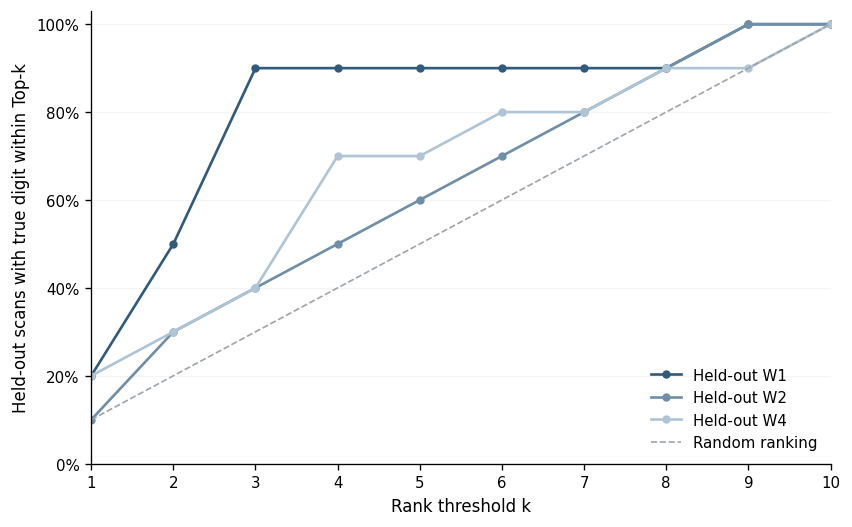

In [7]:
# Figure 1 — complete leave-one-wheel-out rank curves

def cumulative_topk(
    frame
):
    ranks = frame[
        "true_rank"
    ].to_numpy(
        dtype=float
    )

    ks = np.arange(
        1,
        11,
    )

    values = np.array([
        np.mean(
            ranks
            <= k
        )
        for k
        in ks
    ])

    return (
        ks,
        values,
    )


fig, ax = plt.subplots(
    figsize=(
        7.2,
        4.5,
    )
)

curve_rows = []

for (
    wheel,
    color,
) in [
    (
        1,
        DARK_BLUE,
    ),
    (
        2,
        MID_BLUE,
    ),
    (
        4,
        LIGHT_BLUE,
    ),
]:
    frame = decision_predictions[
        decision_predictions[
            "heldout_wheel"
        ]
        == wheel
    ]

    ks, values = cumulative_topk(
        frame
    )

    ax.plot(
        ks,
        100
        * values,
        marker="o",
        markersize=4,
        linewidth=1.6,
        color=color,
        label=(
            f"Held-out W{wheel}"
        ),
    )

    for (
        k,
        value,
    ) in zip(
        ks,
        values,
    ):
        curve_rows.append({
            "heldout_wheel": wheel,
            "k": int(
                k
            ),
            "topk_rate": float(
                value
            ),
        })


ax.plot(
    np.arange(
        1,
        11,
    ),
    10
    * np.arange(
        1,
        11,
    ),
    linestyle="--",
    linewidth=1,
    color=MID_GREY,
    label="Random ranking",
)

ax.set_xlim(
    1,
    10,
)

ax.set_ylim(
    0,
    103,
)

ax.set_xticks(
    np.arange(
        1,
        11,
    )
)

ax.set_yticks(
    np.arange(
        0,
        101,
        20,
    )
)

ax.set_yticklabels([
    f"{v}%"
    for v in np.arange(
        0,
        101,
        20,
    )
])

ax.set_xlabel(
    "Rank threshold k"
)

ax.set_ylabel(
    "Held-out scans with true digit within Top-k"
)

ax.grid(
    axis="y",
    alpha=0.13,
)

ax.legend(
    frameon=False,
    loc="lower right",
)

fig.tight_layout()

save_figure(
    fig,
    "RQ9_Fig1_leave_one_wheel_rank_curves",
)

pd.DataFrame(
    curve_rows
).to_csv(
    RESULT_DIR
    / "RQ9_cumulative_rank_curve.csv",
    index=False,
)

plt.show()

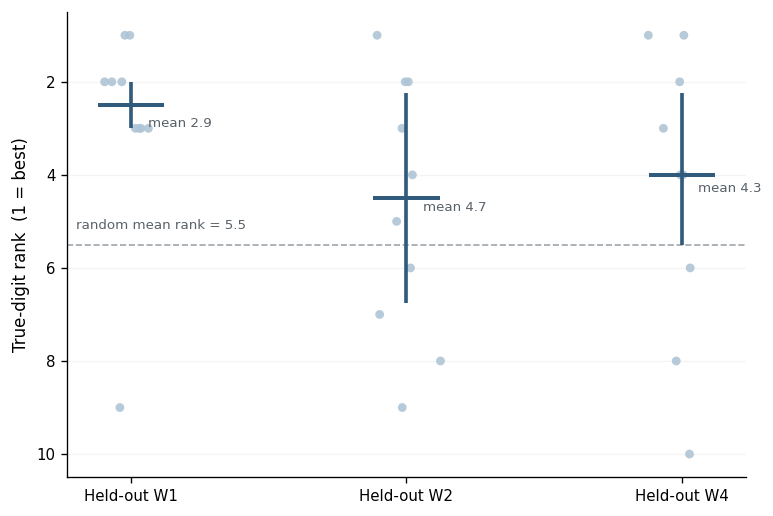

In [8]:
# Figure 2 — raw true ranks on each unseen wheel

fig, ax = plt.subplots(
    figsize=(
        6.6,
        4.4,
    )
)

rng = np.random.default_rng(
    RANDOM_STATE
)

for (
    x_pos,
    wheel,
) in enumerate(
    [
        1,
        2,
        4,
    ],
    start=1,
):
    values = (
        decision_predictions.loc[
            decision_predictions[
                "heldout_wheel"
            ]
            == wheel,
            "true_rank",
        ]
        .to_numpy(
            dtype=float
        )
    )

    x = rng.normal(
        x_pos,
        0.055,
        size=len(
            values
        ),
    )

    ax.scatter(
        x,
        values,
        s=28,
        color=LIGHT_BLUE,
        edgecolor="none",
        alpha=0.9,
        zorder=2,
    )

    q1, median, q3 = np.quantile(
        values,
        [
            0.25,
            0.50,
            0.75,
        ],
    )

    ax.vlines(
        x_pos,
        q1,
        q3,
        color=DARK_BLUE,
        linewidth=2.2,
        zorder=3,
    )

    ax.hlines(
        median,
        x_pos
        - 0.12,
        x_pos
        + 0.12,
        color=DARK_BLUE,
        linewidth=2.4,
        zorder=4,
    )

    mean_value = float(
        np.mean(
            values
        )
    )

    ax.annotate(
        f"mean {mean_value:.1f}",
        xy=(
            x_pos,
            mean_value,
        ),
        xytext=(
            10,
            0,
        ),
        textcoords="offset points",
        va="center",
        fontsize=8,
        color=DARK_GREY,
    )


ax.axhline(
    5.5,
    color=MID_GREY,
    linestyle="--",
    linewidth=1,
)

ax.text(
    0.80,
    5.22,
    "random mean rank = 5.5",
    ha="left",
    va="bottom",
    fontsize=8,
    color=DARK_GREY,
)

ax.set_xticks(
    [
        1,
        2,
        3,
    ]
)

ax.set_xticklabels([
    "Held-out W1",
    "Held-out W2",
    "Held-out W4",
])

ax.set_ylabel(
    "True-digit rank  (1 = best)"
)

ax.set_ylim(
    10.5,
    0.5,
)

ax.grid(
    axis="y",
    alpha=0.13,
)

fig.tight_layout()

save_figure(
    fig,
    "RQ9_Fig2_true_rank_distribution",
)

plt.show()

## 6. Historical reference and result record

The historical Shared Event Ranker v3 result is retained separately because its exact serialized model was not recovered. The fresh reconstruction is the reproducible result used for the main RQ9 analysis.

In [9]:
recorded_reference = pd.DataFrame([
    {
        "artifact": (
            "Shared Event Ranker v3"
        ),
        "recoverability": (
            "Exact serialized historical ranker and exact per-wheel table were not recovered."
        ),
        "recorded_constraints": (
            "No wheel ID; no absolute acoustic fingerprint; normalised event-like features only."
        ),
        "recorded_validation": (
            "Leave-one-wheel-out"
        ),
        "recorded_top1": (
            "approximately 7-13%"
        ),
        "recorded_conclusion": (
            "Some shared event structure exists, but a universal wheel-invariant "
            "10-way detector is not reliable enough."
        ),
    }
])

recorded_reference.to_csv(
    RESULT_DIR
    / "RQ9_recorded_reference.csv",
    index=False,
)

display(
    recorded_reference
)

,artifact,recoverability,recorded_constraints,recorded_validation,recorded_top1,recorded_conclusion
0,Shared Event Ranker v3,Exact serialized historical ranker and exact p...,No wheel ID; no absolute acoustic fingerprint;...,Leave-one-wheel-out,approximately 7-13%,"Some shared event structure exists, but a univ..."


## 7. Tables and final conclusion

In [10]:
table1 = summary.copy()

table1[
    "Top-1"
] = (
    100
    * table1[
        "top1"
    ]
).map(
    lambda x: f"{x:.1f}%"
)

table1[
    "Top-2"
] = (
    100
    * table1[
        "top2"
    ]
).map(
    lambda x: f"{x:.1f}%"
)

table1[
    "Top-3"
] = (
    100
    * table1[
        "top3"
    ]
).map(
    lambda x: f"{x:.1f}%"
)

table1[
    "Mean rank"
] = table1[
    "mean_true_rank"
].map(
    lambda x: f"{x:.2f}"
)

table1[
    "MRR"
] = table1[
    "mrr"
].map(
    lambda x: f"{x:.3f}"
)

table1 = table1[
    [
        "scope",
        "n_scans",
        "Top-1",
        "Top-2",
        "Top-3",
        "Mean rank",
        "MRR",
    ]
].rename(
    columns={
        "scope": (
            "Held-out scope"
        ),
        "n_scans": (
            "N scans"
        ),
    }
)

table1.to_csv(
    RESULT_DIR
    / "RQ9_Table1_LOOW_summary.csv",
    index=False,
)

with open(
    RESULT_DIR
    / "RQ9_Table1_LOOW_summary.tex",
    "w",
    encoding="utf-8",
) as f:
    f.write(
        table1.to_latex(
            index=False,
            escape=True,
        )
    )


table2 = per_wheel_stats.copy()

table2[
    "Top-1"
] = (
    100
    * table2[
        "top1_rate"
    ]
).map(
    lambda x: f"{x:.1f}%"
)

table2[
    "Mean rank"
] = table2[
    "mean_true_rank"
].map(
    lambda x: f"{x:.2f}"
)

table2[
    "Top-1 p"
] = table2[
    "top1_binomial_p"
].map(
    lambda x: f"{x:.3f}"
)

table2[
    "Rank Holm p"
] = table2[
    "rank_wilcoxon_p_holm"
].map(
    lambda x: (
        "<0.001"
        if x < 0.001
        else f"{x:.3f}"
    )
)

table2 = table2[
    [
        "heldout_wheel",
        "n_scans",
        "Top-1",
        "Mean rank",
        "Top-1 p",
        "Rank Holm p",
    ]
].rename(
    columns={
        "heldout_wheel": (
            "Held-out wheel"
        ),
        "n_scans": (
            "N scans"
        ),
    }
)

table2.to_csv(
    RESULT_DIR
    / "RQ9_Table2_inference.csv",
    index=False,
)

with open(
    RESULT_DIR
    / "RQ9_Table2_inference.tex",
    "w",
    encoding="utf-8",
) as f:
    f.write(
        table2.to_latex(
            index=False,
            escape=True,
        )
    )

display(
    table1
)

display(
    table2
)

,Held-out scope,N scans,Top-1,Top-2,Top-3,Mean rank,MRR
0,Overall,30,16.7%,36.7%,56.7%,3.97,0.408
1,W1,10,20.0%,50.0%,90.0%,2.90,0.494
2,W2,10,10.0%,30.0%,40.0%,4.70,0.333
3,W4,10,20.0%,30.0%,40.0%,4.30,0.398


,Held-out wheel,N scans,Top-1,Mean rank,Top-1 p,Rank Holm p
0,1,10,20.0%,2.90,0.264,0.044
1,2,10,10.0%,4.70,0.651,0.244
2,4,10,20.0%,4.30,0.264,0.244


In [11]:
overall = summary[
    summary[
        "scope"
    ]
    == "Overall"
].iloc[
    0
]

conclusion = {
    "research_question": (
        "Can one shortcut-resistant event detector identify the true-gate candidate "
        "on a wheel that was completely absent from training?"
    ),
    "analysis_type": (
        "Controlled leave-one-wheel-out universal-event reconstruction"
    ),
    "dataset": {
        "source": (
            "RQ1-4 controlled validity dataset"
        ),
        "password": (
            "3517"
        ),
        "state": (
            "LOADED"
        ),
        "direction": (
            "CCW"
        ),
        "wheels": [
            1,
            2,
            4,
        ],
        "n_scans": 30,
        "n_candidates": 300,
    },
    "shortcut_restrictions": [
        "No wheel ID",
        (
            "No candidate digit "
            "or transition identity"
        ),
        (
            "No absolute amplitude "
            "or spectral level"
        ),
        (
            "Candidate envelopes "
            "normalised in log domain"
        ),
        (
            "Features robustly normalised "
            "again within each 10-candidate scan"
        ),
        (
            "Only envelope shape, duration, "
            "multi-peak and Ch1-Ch2 transient summaries"
        ),
    ],
    "model": {
        "type": (
            "LogisticRegression"
        ),
        "C": LOGREG_C,
        "class_weight": (
            "balanced"
        ),
        "validation": (
            "Leave one complete wheel out; "
            "train on the other two wheels."
        ),
    },
    "fresh_result": {
        "overall_top1": float(
            overall[
                "top1"
            ]
        ),
        "overall_top2": float(
            overall[
                "top2"
            ]
        ),
        "overall_top3": float(
            overall[
                "top3"
            ]
        ),
        "overall_mean_true_rank": float(
            overall[
                "mean_true_rank"
            ]
        ),
        "overall_mrr": float(
            overall[
                "mrr"
            ]
        ),
        "overall_top1_binomial_p": float(
            overall_top1_test.pvalue
        ),
        "overall_rank_wilcoxon_p": float(
            overall_rank_test.pvalue
        ),
        "per_wheel": summary[
            summary[
                "scope"
            ]
            != "Overall"
        ].to_dict(
            orient="records"
        ),
    },
    "recorded_historical_reference": {
        "name": (
            "Shared Event Ranker v3"
        ),
        "exact_asset_recovered": False,
        "recorded_top1": (
            "approximately 7-13% "
            "under leave-one-wheel-out"
        ),
        "recorded_constraint": (
            "No wheel ID/absolute fingerprint; "
            "normalised event-like features only."
        ),
        "recorded_conclusion": (
            "Some shared event structure exists, "
            "but a universal wheel-invariant detector "
            "is not reliable enough."
        ),
    },
    "interpretation": (
        f"The fresh controlled reconstruction reproduces the historical qualitative failure. "
        f"Overall Top-1 is {100 * overall['top1']:.1f}% versus 10% random and is not significantly "
        f"above chance (one-sided binomial p = {overall_top1_test.pvalue:.3f}). The complete ranking "
        f"is better than random overall (mean true rank {overall['mean_true_rank']:.2f} versus 5.5; "
        f"one-sided Wilcoxon p = {overall_rank_test.pvalue:.4f}), showing that some shared event "
        f"structure is present. However, the held-out-wheel Top-1 results remain low and inconsistent, "
        f"so the shared event is not reliable enough to act as a universal 10-way true-gate detector."
    ),
    "limitation": (
        "The exact historical Shared Event Ranker v3 serialized model was not recovered, "
        "so the fresh result is a transparent reconstruction rather than byte-for-byte replay. "
        "The controlled dataset contains only 10 held-out scans per wheel, so per-wheel "
        "uncertainty is large. The restricted representation also intentionally discards "
        "wheel-specific information that later models use successfully."
    ),
    "decision": (
        "Reject a single universal wheel-invariant event detector as the primary solution. "
        "Retain the evidence that some cross-wheel event structure exists, but allow the "
        "final formulation to use controlled within-scan ranking with wheel-specific adaptation."
    ),
    "next_step": (
        "RQ10 evaluates the alternative Binding-first physical interpretation "
        "and why that hierarchical formulation was also rejected."
    ),
}

with open(
    RESULT_DIR
    / "RQ9_conclusion.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        conclusion,
        f,
        indent=2,
    )


run_info = {
    "notebook": (
        "09_RQ9_Universal_CrossWheel_Event.ipynb"
    ),
    "source_files": [
        (
            "results/00_RQ1-4_QC/"
            "RQ1-4_qc_manifest.csv"
        ),
        (
            "results/feature_cache/"
            "RQ1-4_interpretable_v1.npz"
        ),
    ],
    "feature_source": (
        "Cached 64-bin target/reference envelopes "
        "+ motion duration"
    ),
    "event_feature_count": int(
        X_event.shape[
            1
        ]
    ),
    "candidate_envelope_normalisation": (
        "log envelope -> candidate median subtraction "
        "-> candidate MAD/std scale -> clip"
    ),
    "within_scan_normalisation": (
        "Per-feature median/MAD across the 10 candidates; "
        "std fallback; clip"
    ),
    "classifier": {
        "type": (
            "LogisticRegression"
        ),
        "C": LOGREG_C,
        "solver": (
            "liblinear"
        ),
        "class_weight": (
            "balanced"
        ),
        "random_state": (
            RANDOM_STATE
        ),
    },
    "validation": (
        "Leave-one-wheel-out: held-out W1, W2 or W4 "
        "is never present in training."
    ),
    "chance": {
        "top1": 0.10,
        "top2": 0.20,
        "top3": 0.30,
        "mean_rank": 5.5,
    },
}


with open(
    RESULT_DIR
    / "RQ9_run_info.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        run_info,
        f,
        indent=2,
    )


print(
    json.dumps(
        conclusion,
        indent=2,
    )
)

print(
    "\nSaved outputs:"
)

for path in sorted(
    RESULT_DIR.glob(
        "RQ9_*"
    )
):
    print(
        " -",
        path.name,
    )

{
  "research_question": "Can one shortcut-resistant event detector identify the true-gate candidate on a wheel that was completely absent from training?",
  "analysis_type": "Controlled leave-one-wheel-out universal-event reconstruction",
  "dataset": {
    "source": "RQ1-4 controlled validity dataset",
    "password": "3517",
    "state": "LOADED",
    "direction": "CCW",
    "wheels": [
      1,
      2,
      4
    ],
    "n_scans": 30,
    "n_candidates": 300
  },
  "shortcut_restrictions": [
    "No wheel ID",
    "No candidate digit or transition identity",
    "No absolute amplitude or spectral level",
    "Candidate envelopes normalised in log domain",
    "Features robustly normalised again within each 10-candidate scan",
    "Only envelope shape, duration, multi-peak and Ch1-Ch2 transient summaries"
  ],
  "model": {
    "type": "LogisticRegression",
    "C": 0.01,
    "class_weight": "balanced",
    "validation": "Leave one complete wheel out; train on the other two wheels.